In [150]:
from __future__ import annotations

import operator
from pathlib import Path
from typing import TypedDict,Annotated,List,Literal,Optional

from pydantic import BaseModel,Field

from langgraph.graph import StateGraph,START,END
from langgraph.types import Send

from langchain_groq import ChatGroq
from langchain_core.messages import HumanMessage,SystemMessage
from langchain_community.tools.tavily_search import TavilySearchResults
import os

In [151]:
class Task(BaseModel):
    id: int
    title: str

    goal: str = Field(
        ...,
        description="One sentence describing what the reader should be able to do/understand after this section.",
    )
    bullets: List[str] = Field(
        ...,
        min_length=2,
        max_length=5,
        description="3–5 concrete, non-overlapping subpoints to cover in this section.",
    )
    target_words: int = Field(
        ...,
        description="Target word count for this section (120–550).",
    )
    tags: List[str] = Field(default_factory=list)
    requires_research: bool = False
    requires_citations: bool = False
    requires_code: bool = False


In [152]:
class Plan(BaseModel):
    blog_title: str
    audience: str
    tone: str 
    blog_kind:Literal["explainer", "tutorial", "news_roundup", "comparison", "system_design"]='explainer'
    constraints:List[str]=Field(default_factory=list)
    tasks: List[Task]

In [153]:
class RouterDecision(BaseModel):
    needs_research:bool
    mode:Literal['closed_book','hybrid','open_book']
    queries: List[str] = Field(
        default_factory=list,
        max_length=5
    )

In [154]:
class EvidenceItem(BaseModel):
    title:str
    url:str
    published_at:Optional[str] = None # keep if Tavily provides; DO NOT rely on it
    snippet:Optional[str]=None
    source:Optional[str]=None

In [155]:
class EvidencePack(BaseModel):
    evidence:List[EvidenceItem] = Field(default_factory=list)

In [156]:
class State(TypedDict):
    topic:str

    # routing / research
    mode:str
    needs_research:bool
    queries:List[str]
    evidence:List[EvidenceItem]
    plan:Plan
    
    # reducer: results from workers get concatenated automatically
    sections:Annotated[List[tuple[int,str]],operator.add] 
    final:str

In [157]:
router_llm = ChatGroq(model="llama-3.1-8b-instant",api_key=os.getenv("GROQ_API"))
planner_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API"),
    temperature=0
)
research_llm = ChatGroq(model="llama-3.1-8b-instant",api_key=os.getenv("GROQ_API"))
writer_llm = ChatGroq(
    model="llama-3.3-70b-versatile",
    api_key=os.getenv("GROQ_API"),
    temperature=0.4,
    max_tokens=600
)

In [158]:
ROUTER_SYSTEM = """
You are a routing module for a technical blog planner.

Return a RouterDecision object.

Rules:

1. needs_research MUST be a boolean.

2. mode MUST be exactly one of:
- closed_book
- hybrid
- open_book

3. queries MUST contain at most 5 search queries.

4. Each query must be a COMPLETE Google search query.

GOOD:
- Open source LLMs 2026 comparison
- Best open source LLMs in 2026
- Open source LLM benchmarks 2026

BAD:
- AI
- blog
- 2026
- LLM

5. If mode == closed_book:
queries MUST be []

6. Never generate more than 5 queries.

Return only the RouterDecision object.
"""

def router_node(state:State)->dict:
    topic=state['topic']
    decider = router_llm.with_structured_output(RouterDecision)
    decision = decider.invoke(
        [
            SystemMessage(content=ROUTER_SYSTEM),
            HumanMessage(content=f"topic:{topic}")
        ]
    )

    return {
        "needs_research":decision.needs_research,
        "mode":decision.mode,
        "queries":decision.queries,
    }

def route_next(state : State) -> str:
    if state['needs_research']:
        return 'research'
    else:
        return 'orchestrator'



In [159]:
def research_node(state: State) -> dict:
    queries = (state.get("queries", []) or [])[:3]
    max_results = 3

    raw_results: List[dict] = []

    # Collect Tavily results
    for q in queries:
        raw_results.extend(_tavily_search(q, max_results=max_results))

    if not raw_results:
        return {"evidence": []}

    # Deduplicate by URL
    seen_urls = set()
    evidence: List[EvidenceItem] = []

    for r in raw_results:
        url = (r.get("url") or "").strip()

        if not url or url in seen_urls:
            continue

        seen_urls.add(url)

        evidence.append(
            EvidenceItem(
                title=(r.get("title") or "").strip(),
                url=url,
                snippet=(r.get("snippet") or "")[:300],
                published_at=r.get("published_at"),
                source=r.get("source"),
            )
        )

    return {"evidence": evidence}

In [160]:
import json
from pydantic import ValidationError
from langchain_core.messages import SystemMessage, HumanMessage

ORCH_SYSTEM = """
You are a senior technical blog planner.

Return ONLY valid JSON.

Do NOT wrap the JSON inside markdown.
Do NOT explain anything.
Do NOT use code fences.

JSON schema:

{
  "blog_title": "...",
  "audience": "...",
  "tone": "...",
  "blog_kind": "...",
  "constraints": ["...", "..."],
  "tasks": [
    {
      "id": 1,
      "title": "...",
      "goal": "...",
      "bullets": [
        "...",
        "...",
        "..."
      ],
      "target_words": 200,
      "tags": [],
      "requires_research": false,
      "requires_citations": false,
      "requires_code": false
    }
  ]
}

Rules:
- Create 5-7 tasks.
- Every task MUST have all fields.
- bullets must contain at least 3 items.
- constraints must be a JSON array.
- tasks must be a JSON array.
- Output ONLY JSON.
Return ONLY raw JSON.

Never stringify arrays.

Correct:
"constraints": ["AI","LLM"]

Incorrect:
"constraints": "[\"AI\",\"LLM\"]"

Correct:
"tasks": [...]

Incorrect:
"tasks": "[...]"
"""


def orchestrator_node(state: State) -> dict:

    response = planner_llm.invoke(
        [
            SystemMessage(content=ORCH_SYSTEM),
            HumanMessage(
                content=(
                    f"Topic: {state['topic']}\n"
                    f"Mode: {state['mode']}\n"
                    f"Evidence: {state['evidence']}"
                )
            ),
        ]
    )

    try:
        data = json.loads(response.content)

    except json.JSONDecodeError as e:
        raise ValueError(
            f"Planner returned invalid JSON:\n\n{response.content}"
        ) from e

    try:
        plan = Plan.model_validate(data)

    except ValidationError as e:
        print(response.content)
        raise e

    return {"plan": plan}

In [161]:
# IMPORTANT:
# Send(node_name, state) does NOT call the function directly.
# It tells LangGraph:
# "Run this node with this state."
#
# Returning multiple Send objects = multiple parallel node executions
# (Fan-Out pattern).

def fanout(state: State):
    return [
        Send(
            "worker",
            {
                "task": task,
                "topic": state["topic"],
                "plan": state["plan"],
                "evidence": [e.model_dump() for e in state.get("evidence", [])],
            }
        )
        for task in state["plan"].tasks
    ]

In [162]:
# Worker receives the payload (input state) sent by fanout().
# Payload contains the current task, blog topic, and full plan
# needed to generate one blog section.

def worker(payload: dict) -> dict:

    task = payload["task"]
    topic = payload["topic"]
    plan = payload["plan"]
    evidence = [EvidenceItem(**e) for e in payload.get("evidence", [])]
    topic = payload["topic"]
    mode = payload.get("mode", "closed_book")

    bullets_text = "\n- " + "\n- ".join(task.bullets)

    evidence_text = ""
    if evidence:
            evidence_text = "\n".join(
            f"- {e.title} | {e.url} | {e.published_at or 'date:unknown'}".strip()
            for e in evidence[:8]
        )

    section_md = writer_llm.invoke(
        [
            SystemMessage(
    content=(
         "You are a senior technical writer. "
        "Write ONE Markdown section for a technical blog.\n\n"

        "Requirements:\n"
        "- Cover the Goal and all Bullets in order.\n"
        "- Stay within ±15% of the target word count.\n"
        "- Output ONLY the section Markdown.\n\n"

        "Writing Guidelines:\n"
        "- Be technically accurate and practical.\n"
        "- Use precise developer terminology.\n"
        "- Include a short code example, checklist, or example when appropriate.\n"
        "- Briefly mention trade-offs or edge cases if relevant.\n"
        "- Explain why recommended practices matter.\n\n"

        "Formatting:\n"
        "- Start with '## Section Title'.\n"
        "- Use short paragraphs, bullet lists, and fenced code blocks when useful.\n"
        "- Avoid fluff and marketing language."
    )
)
,
            HumanMessage(
                content=(
                    f"Blog title: {plan.blog_title}\n"
                    ##f"Audience: {plan.audience}\n"
                    ##f"Tone: {plan.tone}\n"
                    ##f"Blog kind: {plan.blog_kind}\n"
                    ##f"Constraints: {plan.constraints}\n"
                    f"Topic: {topic}\n"
                    ##f"Mode: {mode}\n\n"
                    f"Section title: {task.title}\n"
                    f"Goal: {task.goal}\n"
                    ##f"Target words: {task.target_words}\n"
                    ##f"Tags: {task.tags}\n"
                    ##f"requires_research: {task.requires_research}\n"
                    ##f"requires_citations: {task.requires_citations}\n"
                    ##f"requires_code: {task.requires_code}\n"
                    f"Bullets:{bullets_text}\n\n"
                    f"Evidence (ONLY use these URLs when citing):\n{evidence_text}\n"
                )
            ),
        ]
    ).content.strip()

    return {"sections": [(task.id,section_md)]}

In [163]:
# Reducer (Fan-In):
# Collect all Markdown sections generated by parallel workers,
# combine them into a single blog, save it as a .md file,
# and return the final blog content to the graph state.

def reducer(state: State) -> dict:
    
    plan = state["plan"]
    ordered_sections = [
    md for _, md in sorted(state["sections"], key=lambda x: x[0])
    ]

    body = "\n\n".join(ordered_sections).strip()

    final_md = f"# {plan.blog_title}\n\n{body}\n"

    title = plan.blog_title

     # Save to file
    filename = "".join(c if c.isalnum() or c in (" ", "_", "-") else "" for c in title)
    filename = filename.strip().lower().replace(" ", "_") + ".md"
    output_dir = Path("blogs")
    output_dir.mkdir(exist_ok=True)

    (output_dir / filename).write_text(
        final_md,
        encoding="utf-8"
    )

    return {"final": final_md}

In [164]:
g = StateGraph(State)
g.add_node("router", router_node)
g.add_node("research", research_node)
g.add_node("orchestrator", orchestrator_node)
g.add_node("worker", worker)
g.add_node("reducer", reducer)

g.add_edge(START, "router")
g.add_conditional_edges("router", route_next, {"research": "research", "orchestrator": "orchestrator"})
g.add_edge("research", "orchestrator")

g.add_conditional_edges("orchestrator", fanout, ["worker"])
g.add_edge("worker", "reducer")
g.add_edge("reducer", END)

app = g.compile()

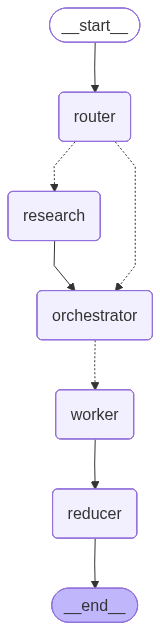

In [165]:
app

In [166]:
def run(topic: str):
    out = app.invoke(
        {
            "topic": topic,
            "mode": "",
            "needs_research": False,
            "queries": [],
            "evidence": [],
            "plan": None,
            "sections": [],
            "final": "",
        }
    )

    return out

In [167]:
run("Write a blog on Open Source LLMs in 2026")

BadRequestError: Error code: 400 - {'error': {'message': 'tool call validation failed: parameters for tool RouterDecision did not match schema: errors: [`/needs_research`: expected boolean, but got string]', 'type': 'invalid_request_error', 'code': 'tool_use_failed', 'failed_generation': '<function=RouterDecision> {"mode": "open_book", "needs_research": "true", "queries": ["Open source LLMs 2026 comparison", "Best open source LLMs in 2026", "Open source LLM benchmarks 2026"]} </function>'}}